In [186]:
import pandas as pd
import seaborn
import seaborn as sns
import xgboost
from catboost import CatBoostRegressor

from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split,cross_val_score,KFold
import numpy as np
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error
import xgboost as xgb
import matplotlib.pyplot as plt
import lightgbm

import optuna
from sklearn.model_selection import cross_val_score,cross_validate,cross_val_predict


In [231]:
def load_data():
    X = pd.read_csv("StudentPerformanceFactors.csv")
    X=X.dropna()
    y = X["Exam_Score"]
    X.drop(columns=["Exam_Score"], inplace=True)
    return X,y
X,y = load_data()
X


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female


<Axes: xlabel='Sleep_Hours', ylabel='Exam_Score'>

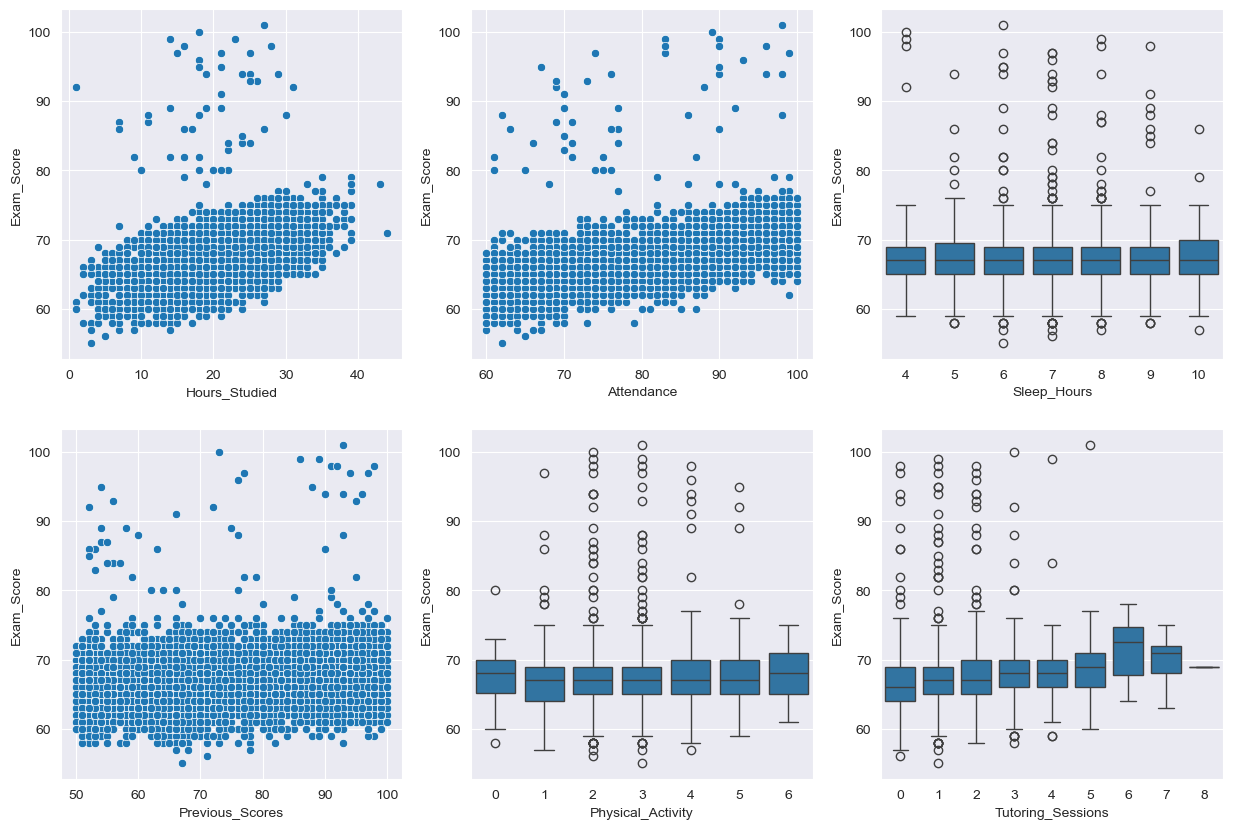

In [2]:
students = pd.read_csv("StudentPerformanceFactors.csv")

fig,axs = plt.subplots(ncols=3,nrows=2,figsize=(15,10))
sns.scatterplot(data=students,x="Hours_Studied",y="Exam_Score",ax=axs[0,0])
sns.scatterplot(data=students,x="Attendance",y="Exam_Score",ax=axs[0,1])
sns.scatterplot(data=students,x="Previous_Scores",y="Exam_Score",ax=axs[1,0])
sns.boxplot(data=students,x="Physical_Activity",y="Exam_Score",ax=axs[1,1])
sns.boxplot(data=students,x="Tutoring_Sessions",y="Exam_Score",ax=axs[1,2])
sns.boxplot(data=students,x="Sleep_Hours",y="Exam_Score",ax=axs[0,2])

## XGB

In [56]:
def objective(trial):
    students = pd.read_csv("StudentPerformanceFactors.csv")
    exam_score = students["Exam_Score"]
    students.drop(columns=["Exam_Score"], axis=1, inplace=True)
    categorical_columns = students.select_dtypes(include=['object']).columns.tolist()
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoded_cats = encoder.fit_transform(students[categorical_columns])
    encoded_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(categorical_columns))
    students = pd.concat(
        [students.drop(columns=categorical_columns).reset_index(drop=True), encoded_df.reset_index(drop=True),

         ], axis=1)



    params = {
        "n_estimators":2000,
    "learning_rate":trial.suggest_float("learning_rate",0.01,0.1,log=True),
    "subsample":0.75,
    "max_depth":4,
    "reg_alpha":trial.suggest_float("reg_alpha",0,3),
        "min_child_weight":trial.suggest_float("min_child_weight",0,20),
    }
    X = students
    y=exam_score
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
    X_test,X_validation,y_test,y_validation=train_test_split(students,exam_score,test_size=0.3,random_state=42)
    model = XGBRegressor(**params,early_stopping_rounds=50)
    model.fit(X_train,y_train,eval_set=[(X_validation,y_validation)],verbose=1000)
    preds = model.predict(X_test)
    r2 = r2_score(y_test,preds)

    return r2

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10,show_progress_bar=True)
print(study.best_params)
#print(root_mean_squared_error(preds, y_test))
#print(r2_score(preds, y_test))
#xgb.plot_importance(model)
#students = pd.read_csv("StudentPerformanceFactors.csv")


[I 2025-11-19 02:59:12,140] A new study created in memory with name: no-name-92ee49ff-d055-44d3-80af-d46af0d991aa


  0%|          | 0/10 [00:00<?, ?it/s]

[0]	validation_0-rmse:3.57101
[275]	validation_0-rmse:1.85903
[I 2025-11-19 02:59:12,842] Trial 0 finished with value: 0.7800019383430481 and parameters: {'learning_rate': 0.07013695674363726, 'reg_alpha': 2.8673451130196677, 'min_child_weight': 16.24449937064049}. Best is trial 0 with value: 0.7800019383430481.
[0]	validation_0-rmse:3.63551
[417]	validation_0-rmse:1.85094
[I 2025-11-19 02:59:13,561] Trial 1 finished with value: 0.781110405921936 and parameters: {'learning_rate': 0.03636288521265806, 'reg_alpha': 0.2784867462190349, 'min_child_weight': 12.490976345678737}. Best is trial 1 with value: 0.781110405921936.
[0]	validation_0-rmse:3.67677
[777]	validation_0-rmse:1.85454
[I 2025-11-19 02:59:14,600] Trial 2 finished with value: 0.7780628800392151 and parameters: {'learning_rate': 0.015224064352924754, 'reg_alpha': 0.22737234681198082, 'min_child_weight': 7.328368086165112}. Best is trial 1 with value: 0.781110405921936.
[0]	validation_0-rmse:3.68387
[1000]	validation_0-rmse:1.8

[0]	validation_0-rmse:3.81757
[100]	validation_0-rmse:2.35583
[200]	validation_0-rmse:2.16963
[300]	validation_0-rmse:2.12803
[400]	validation_0-rmse:2.12713
[405]	validation_0-rmse:2.12797
R2 test 0.7927509936391393 
R2 full 0.804703214434326 
RMSE test 2.7082174361174776 
RMSE full 1.7191555054525327 


<Axes: ylabel='Exam_Score'>

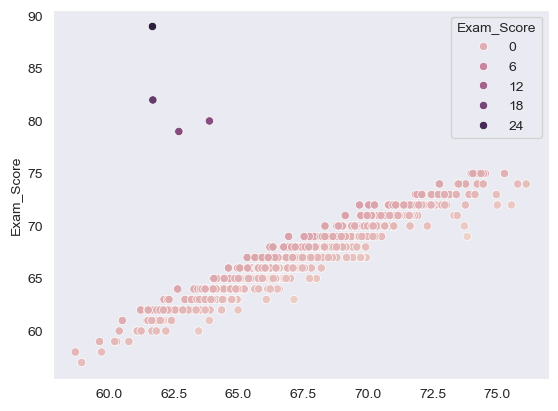

In [210]:
X,y = load_data()
categorical_columns = X.select_dtypes(include="object").columns.tolist()
X[categorical_columns] = X[categorical_columns].astype("category")
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
X_test,X_validation,y_test,y_validation=train_test_split(X_test,y_test,test_size=0.6,random_state=42)
model = XGBRegressor(n_estimators=1500,learning_rate=0.02,enable_categorical=True,random_state=42,early_stopping_rounds = 50)
model.fit(X_train,y_train,eval_set=[(X_validation,y_validation)],verbose=100)
preds = model.predict(X_test)
preds_full = model.predict(X)
resid = preds_full-y

print(f'R2 test {r2_test} ')
print(f'R2 full {r2_full} ')
print(f'RMSE test {rmse} ')
print(f'RMSE full {rmse_full} ')
resid = y_test-preds
#xgboost.plot_importance(model)
sns.scatterplot(x=preds,y=y_test,hue  =resid)

## CAT

In [217]:
X,y = load_data()

categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_columns] = X[categorical_columns].fillna("NaN")
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.6,random_state=42)
model_cat =CatBoostRegressor(use_best_model=True,early_stopping_rounds=50)
model_cat.fit(X_train,y_train,cat_features=categorical_columns,eval_set=[(X_validation,y_validation)],verbose=100)
preds = model_cat.predict(X_test)
r2_test=r2_score(y_test,preds)
preds_full =model_cat.predict(X)
r2_full = r2_score(y,preds_full)
rmse = root_mean_squared_error(y_test,preds)
rmse_full = root_mean_squared_error(y,preds_full)
print(f'R2 test {r2_test} ')
print(f'R2 full {r2_full} ')
print(f'RMSE test {rmse} ')
print(f'RMSE full {rmse_full} ')


ValueError: Found input variables with inconsistent numbers of samples: [6378, 6607]

## LGBM

In [241]:

X,y =  load_data()

categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_columns] = X[categorical_columns].astype("category")

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.6,random_state=42)

model = lightgbm.LGBMRegressor(random_state=42,early_stopping_rounds = 50,n_estimators=5000)
model.fit(X_train,y_train,categorical_feature=categorical_columns,eval_set=[(X_validation,y_validation)])
preds = model.predict(X_test)
preds_full = model.predict(X)
r2 = r2_score(y_test,preds)
r2_full = r2_score(y,preds_full)
rmse = root_mean_squared_error(y_test,preds)
rmse_full = root_mean_squared_error(y,preds_full)
print(f'R2 test {r2_test} ')
print(f'R2 full {r2_full} ')
print(f'RMSE test {rmse} ')
print(f'RMSE full {rmse_full} ')


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[75]	valid_0's l2: 4.8226
R2 test 0.7927509936391393 
R2 full 0.8040028445273295 
RMSE test 2.088283403353381 
RMSE full 1.7327490896244027 


In [222]:
X,y = load_data()
X=X.dropna()
X

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female


In [197]:
X,y =  load_data()
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_columns] = X[categorical_columns].fillna("NaN")
X[categorical_columns] = X[categorical_columns].astype("category")

X,X_val,y,y_val = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)
xgb = XGBRegressor(random_state=42,enable_categorical=True,early_stopping_rounds=50)
cat = CatBoostRegressor(random_state=42,use_best_model=True,early_stopping_rounds=50)
lgbm = lightgbm.LGBMRegressor(random_state=42,use_best_model=True,early_stopping_rounds=50,verbosity=-1)
print(np.mean(cross_validate(cat,X,y,params={"cat_features": categorical_columns,"eval_set":[(X_val,y_val)],"verbose":500})["test_score"]))
print(np.mean(cross_validate(xgb,X,y,params={"eval_set":[(X_val,y_val)],"verbose":0})["test_score"]))
print(np.mean(cross_validate(lgbm,X,y,params={"eval_set":[(X_val,y_val)]})["test_score"]))

Learning rate set to 0.063856
0:	learn: 3.8888208	test: 3.6391018	best: 3.6391018 (0)	total: 27.4ms	remaining: 27.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.864952857
bestIteration = 372

Shrink model to first 373 iterations.
Learning rate set to 0.063856
0:	learn: 3.8532483	test: 3.6426357	best: 3.6426357 (0)	total: 39.3ms	remaining: 39.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.864469674
bestIteration = 289

Shrink model to first 290 iterations.
Learning rate set to 0.063856
0:	learn: 3.8016404	test: 3.6496949	best: 3.6496949 (0)	total: 26ms	remaining: 25.9s
500:	learn: 1.6347503	test: 1.8474717	best: 1.8468118 (450)	total: 13.6s	remaining: 13.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.846811794
bestIteration = 450

Shrink model to first 451 iterations.
Learning rate set to 0.063856
0:	learn: 3.7762745	test: 3.6444486	best: 3.6444486 (0)	total: 27.1ms	remaining: 27.1s
Stopped by overfitting detector  